In [1]:
import yfinance as yf
import pandas as pd

data = yf.download("^NSEBANK", start="2020-01-01", end="2024-01-01")

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open   Volume
Ticker          ^NSEBANK      ^NSEBANK      ^NSEBANK      ^NSEBANK ^NSEBANK
Date                                                                       
2020-01-01  32102.527344  32347.624105  32056.826703  32237.525775   184700
2020-01-02  32443.472656  32465.072015  32121.027184  32132.777047   253600
2020-01-03  32068.876953  32329.424704  31960.028610  32326.573174   217600
2020-01-06  31236.787109  31914.078061  31170.188275  31910.078107   256200
2020-01-07  31399.035156  31851.078726  31200.537465  31597.683236   294400


In [2]:
data["SMA20"] = data["Close"].rolling(20).mean()
data["SMA50"] = data["Close"].rolling(50).mean()

In [3]:
data["Signal"] = 0

data.loc[data["SMA20"] > data["SMA50"], "Signal"] = 1
data.loc[data["SMA20"] < data["SMA50"], "Signal"] = -1

In [4]:
data["Market_Return"] = data["Close"].pct_change()

data["Strategy_Return"] = data["Market_Return"] * data["Signal"].shift(1)

In [5]:
data["Cumulative_Return"] = (1 + data["Strategy_Return"]).cumprod()

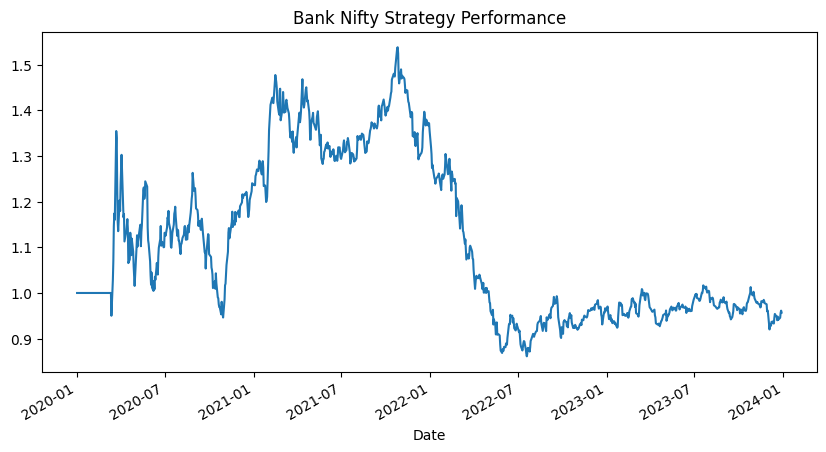

In [6]:
import matplotlib.pyplot as plt

data["Cumulative_Return"].plot(figsize=(10,5))
plt.title("Bank Nifty Strategy Performance")
plt.show()

In [7]:
print("Total Return:", data["Cumulative_Return"].iloc[-1])

Total Return: 0.9570445812848422


In [8]:
sharpe = data["Strategy_Return"].mean() / data["Strategy_Return"].std() * (252 ** 0.5)
print("Sharpe:", sharpe)

Sharpe: 0.08963148903950721


In [9]:
cum = data["Cumulative_Return"]
drawdown = (cum / cum.cummax()) - 1
print("Max Drawdown:", drawdown.min())

Max Drawdown: -0.43992283836144364


In [10]:
print(data["Signal"].value_counts())

Signal
 1    592
-1    350
 0     49
Name: count, dtype: int64


<Axes: xlabel='Date'>

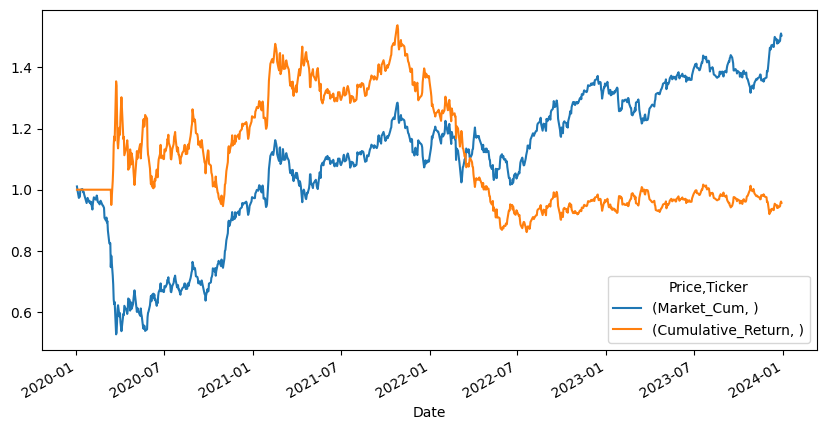

In [11]:
data["Market_Cum"] = (1 + data["Market_Return"]).cumprod()

data[["Market_Cum","Cumulative_Return"]].plot(figsize=(10,5))